In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas
import os

os.chdir('./Data')

# Set global plotting parameters
font = {'size'   : 22}
matplotlib.rc('font', **font)
matplotlib.rcParams['lines.linewidth'] = 2
matplotlib.rcParams['figure.figsize'] = (8, 6)


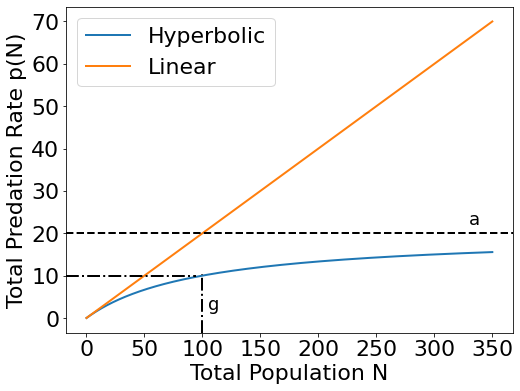

In [2]:
### Figure 1

a = 20
g = 100
m = a/g

hyperbolic = lambda x : a*x/(g+x)
linear = lambda x : m*x

X = np.linspace(0,350,1000)

plt.plot(X, hyperbolic(X), label = 'Hyperbolic')
plt.plot(X, linear(X), label = 'Linear')
plt.xlabel('Total Population N')
plt.ylabel('Total Predation Rate p(N)')
plt.axhline(y=20, color='black', linestyle='--')
plt.axhline(y=10,xmax=0.29, color='black', linestyle='-.')
plt.axvline(x=100,ymax=0.179, color='black', linestyle='-.')
plt.text(330, 22, 'a',fontsize = 18)
plt.text(105, 2, 'g',fontsize = 18)
plt.xticks(np.arange(0, 355, 50))
plt.yticks(np.arange(0, 72, 10))
plt.legend()
#plt.savefig('Fig1.eps', format='eps', bbox_inches='tight')
plt.show()

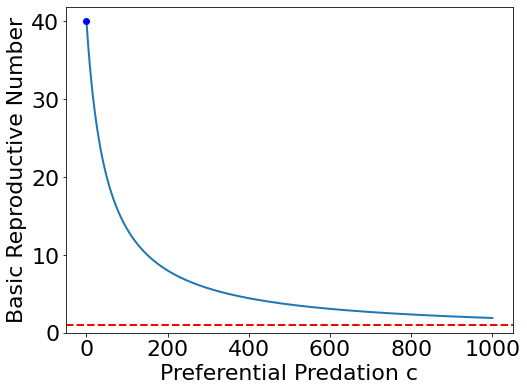

In [3]:
### Figure 3 (a)

Beta = 2
b = 10
g = 100
a = 20
Delta = 5
f = lambda x : (Beta*b*(g**2))/((a-b)*(Delta*g+a*x-b*x))

X = np.linspace(0, 1000, 1000)
Y = f(X)

plt.plot(X,Y)
plt.plot([0],f(0),'or', color = "blue")
plt.xlabel('Preferential Predation c')
plt.ylabel('Basic Reproductive Number')
plt.axhline(y=1, color='r', linestyle='--')
plt.yticks(np.arange(0, 45, 10))
#plt.savefig('Fig7a.eps', format='eps', bbox_inches='tight')
plt.show()

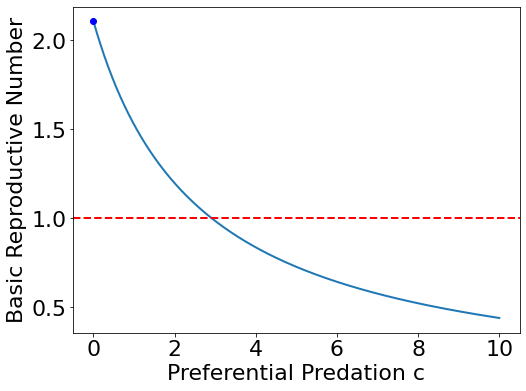

In [4]:
### Figure 3 (b)

a = 200

X = np.linspace(0, 10, 1000)
Y = f(X)

plt.plot(X,Y)
plt.plot([0],f(0),'or', color = "blue")
plt.xlabel('Preferential Predation c')
plt.ylabel('Basic Reproductive Number')
plt.axhline(y=1, color='r', linestyle='--')
#plt.savefig('Fig7b.eps', format='eps', bbox_inches='tight')
plt.show()

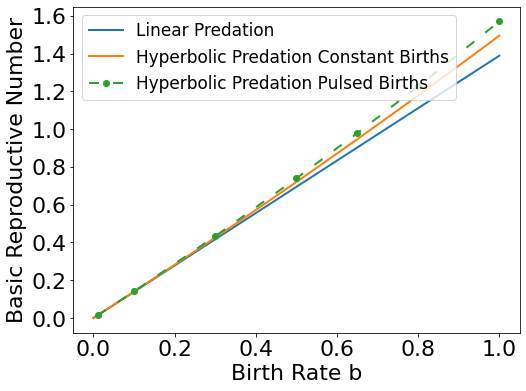

In [5]:
### Figure 4(a)

X1 = np.linspace(0,1,1000)

a = 20
beta = 50
c = 1
g = 5
d = a/g
delta = 5

# Read in the CSV file
csvFile4a = pandas.read_csv('Fig4a_data.csv')

b_val = csvFile4a['b_val']
int_S = csvFile4a['int_S']
int_g = csvFile4a['int_g']

num = int_S * beta
denom = int_g *c*a + delta

plt.plot(X1,(beta*X1)/(d**2+d*delta),label = 'Linear Predation')
plt.plot(X1,(beta*X1*g**2)/((a-X1)*(delta*g+c*(a-X1))), label = 'Hyperbolic Predation Constant Births')
plt.plot(b_val,num/denom,'--o', label = 'Hyperbolic Predation Pulsed Births', dashes = (5,7))
plt.legend(fontsize = 17)
plt.ylabel('Basic Reproductive Number')
plt.xlabel('Birth Rate b')
plt.yticks(np.arange(0, 1.8, 0.20))
#plt.savefig('Fig5a.eps', format='eps', bbox_inches='tight')
plt.show()

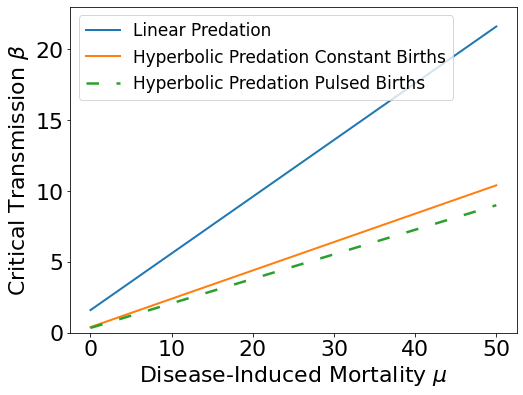

In [6]:
### Figure 4 (b)

# Read in the CSV file
csvFile4bcd = pandas.read_csv('Fig4bcd_data.csv')

# Extract data for this figure
int_S = csvFile4bcd.loc[csvFile4bcd['fig_letter'] == 'b', 'int_S'].iloc[0]
int_g = csvFile4bcd.loc[csvFile4bcd['fig_letter'] == 'b', 'int_g'].iloc[0]

X = np.linspace(0,50,1000)

a = 20
c = 1
g = 5
b = 10

plt.plot(X, ((a/g)*X+(a/g)**2)/b, label = 'Linear Predation')
plt.plot(X,((a-b)*(X*g+c*(a-b)))/(b*g**2), label = 'Hyperbolic Predation Constant Births')
plt.plot(X,(X+a*c*(int_g))/(int_S),'--',dashes=(5,7),linewidth = 2.5,label = 'Hyperbolic Predation Pulsed Births')
plt.ylim(ymin=0,ymax=23)
plt.ylabel('Critical Transmission ' r'$\beta$')
plt.xlabel(r'Disease-Induced Mortality $\mu$')
plt.legend(fontsize = 17)
#plt.savefig('Fig5b.eps', format='eps', bbox_inches='tight')
plt.show()

RelativeDiff4b = (((X+a*c*(int_g))/(int_S)) - (((a-b)*(X*g+c*(a-b)))/(b*g**2))) / (((a-b)*(X*g+c*(a-b)))/(b*g**2))

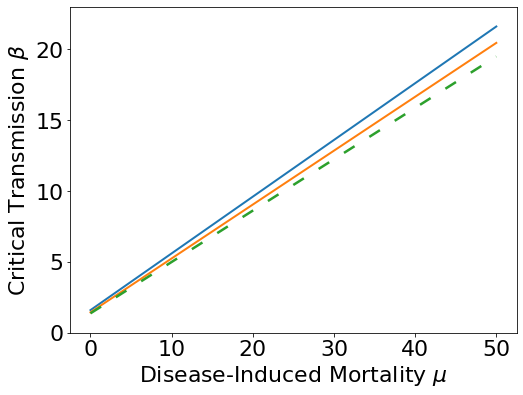

In [7]:
### Figure 4 (c)

# Extract data for this figure
int_S = csvFile4bcd.loc[csvFile4bcd['fig_letter'] == 'c', 'int_S'].iloc[0]
int_g = csvFile4bcd.loc[csvFile4bcd['fig_letter'] == 'c', 'int_g'].iloc[0]

a = 200
c = 1
g = 50
b = 10

plt.plot(X, ((a/g)*X+(a/g)**2)/b)
plt.plot(X,((a-b)*(X*g+c*(a-b)))/(b*g**2))
plt.plot(X,(X+a*c*(int_g))/(int_S),'--',dashes=(5,7),linewidth = 2.5,label = 'Hyperbolic Predation Pulsed Births')
plt.ylim(ymin=0,ymax=23)
plt.ylabel('Critical Transmission ' r'$\beta$')
plt.xlabel(r'Disease-Induced Mortality $\mu$')
#plt.savefig('Fig5c.eps', format='eps', bbox_inches='tight')
plt.show()

RelativeDiff4c = (((X+a*c*(int_g))/(int_S)) - (((a-b)*(X*g+c*(a-b)))/(b*g**2))) / (((a-b)*(X*g+c*(a-b)))/(b*g**2))

In [8]:
# the relative difference between pulsed and constant births is larger in 4b
sum(np.abs(RelativeDiff4b) < np.abs(RelativeDiff4c))

0

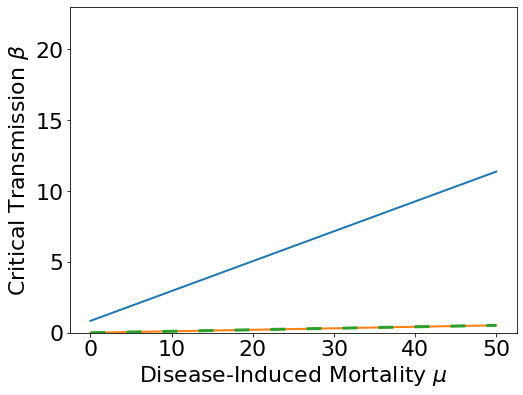

In [9]:
### Figure 4 (d)

# Extract data for this figure
int_S = csvFile4bcd.loc[csvFile4bcd['fig_letter'] == 'd', 'int_S'].iloc[0]
int_g = csvFile4bcd.loc[csvFile4bcd['fig_letter'] == 'd', 'int_g'].iloc[0]

a = 20
c = 1
g = 5
b = 19

plt.plot(X, ((a/g)*X+(a/g)**2)/b)
plt.plot(X,((a-b)*(X*g+c*(a-b)))/(b*g**2))
plt.plot(X,(X+a*c*(int_g))/(int_S),'--',dashes=(5,7),linewidth = 3) #birth pulse = 19
plt.ylim(ymin=0,ymax=23)
plt.ylabel('Critical Transmission ' r'$\beta$')
plt.xlabel(r'Disease-Induced Mortality $\mu$')
#plt.savefig('Fig5d.eps', format='eps', bbox_inches='tight')
plt.show()

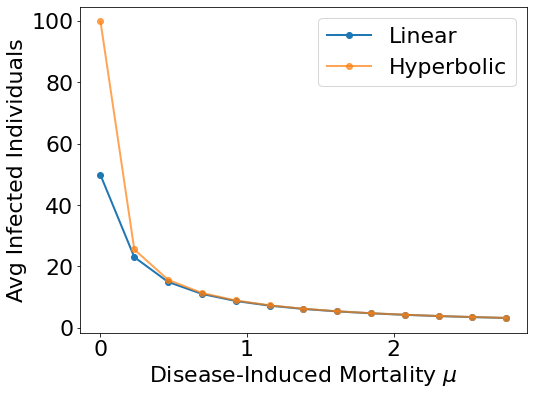

In [10]:
### Figure 6 (a)

# Read in the CSV file
csvFile6_lin = pandas.read_csv('Fig6_linear_data.csv')
csvFile6_hyp = pandas.read_csv('Fig6_hyperbolic_data.csv')

# Subset to small delta values
subset_lin = csvFile6_lin[csvFile6_lin['delta_val'] < 3].copy()
subset_hyp = csvFile6_hyp[csvFile6_hyp['delta_val'] < 3].copy()

# Plot avg infection versus delta
plt.plot(subset_lin['delta_val'],subset_lin['Avg_Infect_over_1_period'],'-o',label='Linear')
plt.plot(subset_hyp['delta_val'],subset_hyp['Avg_Infect_over_1_period'],'-o',label='Hyperbolic',alpha = 0.7)
plt.xlabel('Disease-Induced Mortality 'r'$\mu$')
plt.ylabel('Avg Infected Individuals')
plt.legend(loc = 1)
#plt.yscale('log')
#plt.savefig('Fig10a.eps', format='eps', bbox_inches='tight')
plt.show()

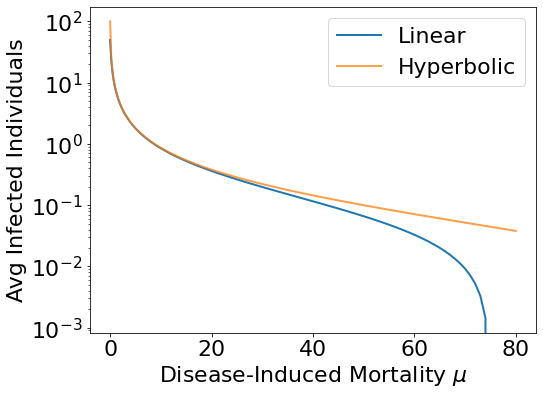

In [11]:
### Figure 6 (b)

csvFile6_lin = csvFile6_lin.round({'Avg_Infect_over_1_period':18})

# Drop rows where avg infection over 1 period couldn't be calculated
csvFile6_hyp_clean = csvFile6_hyp.dropna(subset=['Avg_Infect_over_1_period'])
csvFile6_lin_clean = csvFile6_lin.dropna(subset=['Avg_Infect_over_1_period'])

#Plot avg infection versus delta
plt.figure(figsize=(8,6))
plt.plot(csvFile6_lin_clean['delta_val'],csvFile6_lin_clean['Avg_Infect_over_1_period'],'-',label='Linear')
plt.plot(csvFile6_hyp_clean['delta_val'],csvFile6_hyp_clean['Avg_Infect_over_1_period'],'-',label='Hyperbolic',alpha=0.75)
plt.xlabel('Disease-Induced Mortality 'r'$\mu$')
plt.ylabel('Avg Infected Individuals')
plt.legend(loc = 1)
plt.yscale('log')
#plt.savefig('Fig10b.eps', format='eps', bbox_inches='tight')
plt.show()

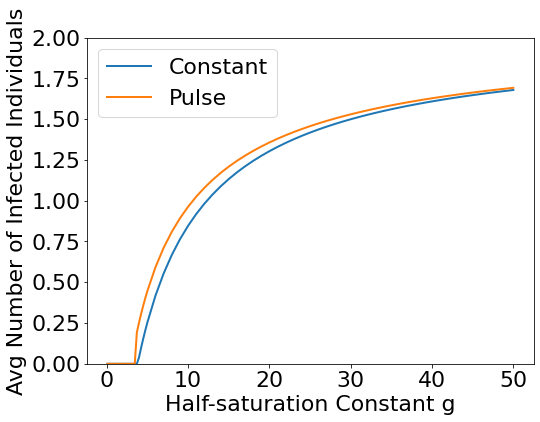

In [12]:
### Figure 7 (a)

csvFile7a_constant = pandas.read_csv('Fig7a_constant_data.csv')
csvFile7a_pulse = pandas.read_csv('Fig7a_pulse_data.csv')

plt.plot(csvFile7a_constant['g_val'],csvFile7a_constant['Avg_Infect_over_1_period'],'-',label='Constant')
plt.plot(csvFile7a_pulse['g_val'],csvFile7a_pulse['Avg_Infect_over_1_period'],'-',label='Pulse')
plt.legend(loc=2)
plt.ylim(ymin=0,ymax=2)
plt.ylabel('Avg Number of Infected Individuals')
plt.xlabel('Half-saturation Constant g')
plt.yticks(np.arange(0, 2.2, 0.25))
#plt.savefig('Fig13a.eps', format='eps', bbox_inches='tight')
plt.show()

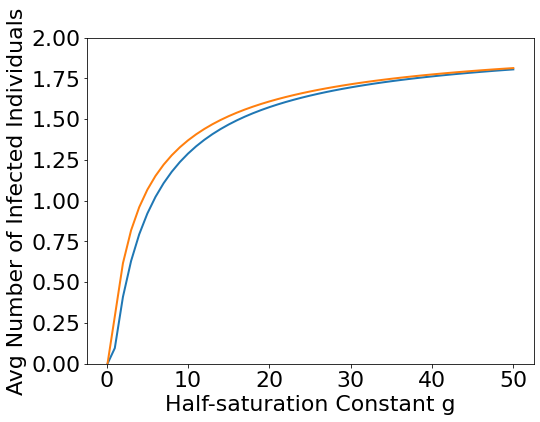

In [13]:
### Figure 7 (b)

csvFile7b_pulse = pandas.read_csv('Fig7b_pulse_data.csv')
csvFile7b_constant = pandas.read_csv('Fig7b_constant_data.csv')

plt.plot(csvFile7b_constant['g_val'],csvFile7b_constant['Avg_Infect_over_1_period'],'-',label='Constant')
plt.plot(csvFile7b_pulse['g_val'],csvFile7b_pulse['Avg_Infect_over_1_period'],'-',label='Pulse')
plt.xlabel('Half-saturation Constant g')
plt.ylabel('Avg Number of Infected Individuals')
plt.ylim(ymin=0,ymax=2)
plt.yticks(np.arange(0, 2.2, 0.25))
#plt.savefig('Fig13b.eps', format='eps', bbox_inches='tight')
plt.show()

<ipython-input-14-770d9ab4038e>:7: RuntimeWarning: divide by zero encountered in true_divide
  RelativeDiff_a = (pulse-constant)/constant
<ipython-input-14-770d9ab4038e>:7: RuntimeWarning: invalid value encountered in true_divide
  RelativeDiff_a = (pulse-constant)/constant
<ipython-input-14-770d9ab4038e>:11: RuntimeWarning: divide by zero encountered in true_divide
  RelativeDiff_b = (pulse - constant)/constant


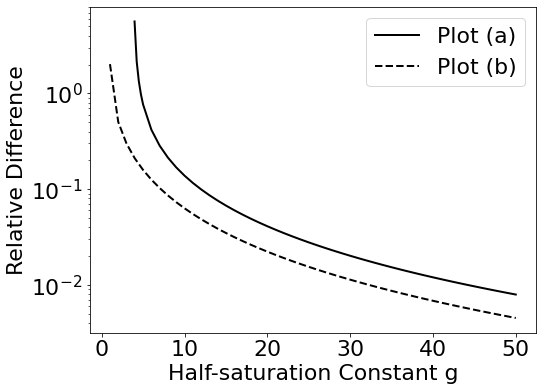

In [14]:
### Figure 7 (c)

csvFile7a_constant = csvFile7a_constant.round({'Avg_Infect_over_1_period':18})

constant = np.array(csvFile7a_constant['Avg_Infect_over_1_period'])
pulse = np.array(csvFile7a_pulse['Avg_Infect_over_1_period'])
RelativeDiff_a = (pulse-constant)/constant

constant = np.array(csvFile7b_constant['Avg_Infect_over_1_period'])
pulse = np.array(csvFile7b_pulse['Avg_Infect_over_1_period'])
RelativeDiff_b = (pulse - constant)/constant

plt.plot(csvFile7a_pulse['g_val'],RelativeDiff_a,'-', label = 'Plot (a)',color = 'Black')
plt.plot(csvFile7b_pulse['g_val'],RelativeDiff_b,'--',label='Plot (b)', color = 'Black')
plt.legend()
plt.yscale('log')
plt.xlabel('Half-saturation Constant g')
plt.ylabel('Relative Difference')
#plt.savefig('Fig13c.eps', format='eps', bbox_inches='tight')
plt.show()

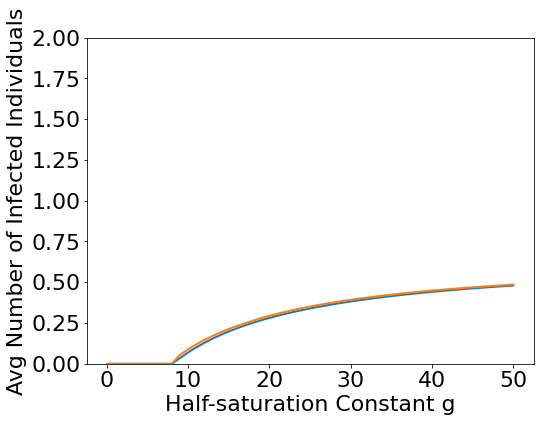

In [15]:
### Figure 7 (d)

csvFile7d_constant = pandas.read_csv('Fig7d_constant_data.csv')
csvFile7d_pulse = pandas.read_csv('Fig7d_pulse_data.csv')

# Drop rows where avg infection over 1 period couldn't be calculated
csvFile7d_pulse_clean = csvFile7d_pulse.dropna(subset=['Avg_Infect_over_1_period'])

plt.plot(csvFile7d_constant['g_val'],csvFile7d_constant['Avg_Infect_over_1_period'],label='Constant')
plt.plot(csvFile7d_pulse_clean['g_val'],csvFile7d_pulse_clean['Avg_Infect_over_1_period'],label='Pulse')
plt.xlabel('Half-saturation Constant g')
plt.ylabel('Avg Number of Infected Individuals')
plt.ylim(ymin=0,ymax=2)
plt.yticks(np.arange(0, 2.2, 0.25))
#plt.savefig('Fig13d.eps', format='eps', bbox_inches='tight')
plt.show()